In [ ]:
import pyodbc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import xgboost as xgb


In [ ]:
# ------------------------------
# 1. Load and preprocess match data
# ------------------------------

conn_str = "DRIVER={ODBC Driver 17 for SQL Server};SERVER=localhost;DATABASE=PL-prediction-db;UID=lilian;PWD=12345678;"
def get_conn():
    return pyodbc.connect(conn_str)

def get_all_fixtures():
    rows = []
    with get_conn() as conn:
        query = "SELECT * FROM pl.pl_fixtures"
        df = pd.read_sql(query, conn)
    return df
    
matches_df = get_all_fixtures()

# Load match data (update the file path as needed)
Urls = ["https://github.com/yuliang419/football-predictor/blob/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_processed_results.csv?raw=true", 
        "https://raw.githubusercontent.com/yuliang419/football-predictor/6d8b6b6ed2ad049012c8d3192146dde8e7a6de93/data/EPL_Standings.csv?raw=true"]

def getCsv(csvUrl):
        df = pd.read_csv(csvUrl)
        if "Unnamed: 0" in df.columns:
                df.rename(columns={"Unnamed: 0": "fixture_id"}, inplace=True)
        return df
# matches_df = getCsv(Urls[0])


C:\Users\tokam\AppData\Local\Temp\ipykernel_30336\2666267599.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [21]:

# For reproducibility, sort by Season (assuming Season is sortable, e.g., '2003/2004', etc.)
matches_df['Season'] = matches_df['Season'].astype(str)
unique_seasons = sorted(matches_df['Season'].unique())

# Define time-based split percentages
n_seasons = len(unique_seasons)
train_end = int(0.6 * n_seasons)
val_end = int(0.8 * n_seasons)

train_seasons = unique_seasons[:train_end]
val_seasons   = unique_seasons[train_end:val_end]
test_seasons  = unique_seasons[val_end:]

# Split the dataset based on Season
train_df = matches_df[matches_df['Season'].isin(train_seasons)]
val_df   = matches_df[matches_df['Season'].isin(val_seasons)]
test_df  = matches_df[matches_df['Season'].isin(test_seasons)]

print(f"Train seasons: {train_seasons}")
print(f"Validation seasons: {val_seasons}")
print(f"Test seasons: {test_seasons}")


Train seasons: ['1993-94', '1994-95', '1995-96', '1996-97', '1997-98', '1998-99', '1999-00', '2000-01', '2001-02', '2002-03', '2003-04', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10']
Validation seasons: ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16']
Test seasons: ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22']


In [22]:
# ------------------------------
# 2. Feature Engineering & Target Encoding
# ------------------------------

# Define the features – adjust these based on available columns and domain knowledge
feature_cols = [
    'StandingDiff', 'HomeWins', 'AwayWins', 'HomeDraws', 'AwayDraws',
    'AvgHomeGoals', 'AvgAwayGoals', 'AvgHomeShots', 'AvgAwayShots',
    'AvgHomeShotsOnTarget', 'AvgAwayShotsOnTarget', 'AvgHomeCorners',
    'AvgAwayCorners', 'AvgHomeGoalsConceded', 'AvgAwayGoalsConceded',
    'AvgHomeShotsConceded', 'AvgAwayShotsConceded'
]

# Ensure that the chosen feature columns exist in your data
missing_features = [col for col in feature_cols if col not in train_df.columns]
if missing_features:
    raise ValueError(f"Missing columns in data: {missing_features}")

# Encode target variable FTR ("H", "D", "A") to numeric labels
label_encoder = LabelEncoder()
for df in [train_df, val_df, test_df]:
    df['FTR_encoded'] = label_encoder.fit_transform(df['FullTimeResults'])
    
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Extract features and target for each split
def get_xy(df, features, target_col='FTR_encoded'):
    X = df[features].values
    y = df[target_col].values
    return X, y

X_train, y_train = get_xy(train_df, feature_cols)
X_val, y_val     = get_xy(val_df, feature_cols)
X_test, y_test   = get_xy(test_df, feature_cols)

# Optionally, standardize features. While XGBoost is tree-based (and often does not require scaling),
# standardization can still help if you later compare with other models.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


Label mapping: {'A': 0, 'D': 1, 'H': 2}


C:\Users\tokam\AppData\Local\Temp\ipykernel_30336\458551059.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FTR_encoded'] = label_encoder.fit_transform(df['FullTimeResults'])
C:\Users\tokam\AppData\Local\Temp\ipykernel_30336\458551059.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FTR_encoded'] = label_encoder.fit_transform(df['FullTimeResults'])
C:\Users\tokam\AppData\Local\Temp\ipykernel_30336\458551059.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [23]:
# ------------------------------
# 3. Train the XGBoost Classifier with Early Stopping
# ------------------------------

# Convert to DMatrix (XGBoost’s internal data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)

# Set hyperparameters – these can be tuned further
params = {
    'objective': 'multi:softmax',  # Alternatively, use 'multi:softprob' for probability outputs
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'eta': 0.1,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

watchlist = [(dtrain, 'train'), (dval, 'eval')]

# Train with early stopping on the validation set
model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=watchlist,
    early_stopping_rounds=20,
    verbose_eval=True
)


[0]	train-mlogloss:1.08334	eval-mlogloss:1.09338
[1]	train-mlogloss:1.06955	eval-mlogloss:1.08708
[2]	train-mlogloss:1.05784	eval-mlogloss:1.08343
[3]	train-mlogloss:1.04777	eval-mlogloss:1.08028
[4]	train-mlogloss:1.03862	eval-mlogloss:1.07562
[5]	train-mlogloss:1.03078	eval-mlogloss:1.07539
[6]	train-mlogloss:1.02291	eval-mlogloss:1.07500
[7]	train-mlogloss:1.01592	eval-mlogloss:1.07302
[8]	train-mlogloss:1.01002	eval-mlogloss:1.07208
[9]	train-mlogloss:1.00438	eval-mlogloss:1.07036
[10]	train-mlogloss:0.99932	eval-mlogloss:1.06940
[11]	train-mlogloss:0.99443	eval-mlogloss:1.06818
[12]	train-mlogloss:0.98992	eval-mlogloss:1.06847
[13]	train-mlogloss:0.98595	eval-mlogloss:1.06692
[14]	train-mlogloss:0.98228	eval-mlogloss:1.06535
[15]	train-mlogloss:0.97841	eval-mlogloss:1.06450
[16]	train-mlogloss:0.97541	eval-mlogloss:1.06356
[17]	train-mlogloss:0.97254	eval-mlogloss:1.06340
[18]	train-mlogloss:0.96955	eval-mlogloss:1.06326
[19]	train-mlogloss:0.96688	eval-mlogloss:1.06361
[20]	train

Classification Report on Test Data:
              precision    recall  f1-score   support

           A       0.46      0.14      0.22       693
           D       0.23      0.22      0.22       478
           H       0.51      0.77      0.61       957

    accuracy                           0.44      2128
   macro avg       0.40      0.38      0.35      2128
weighted avg       0.43      0.44      0.40      2128



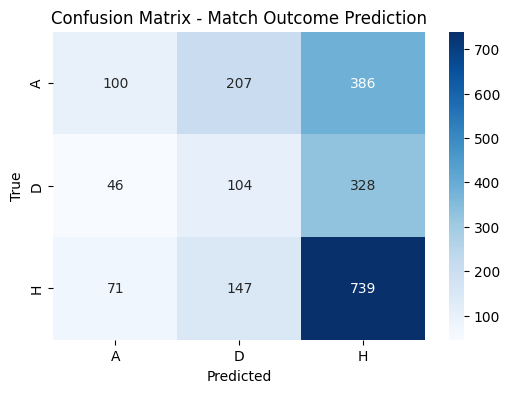

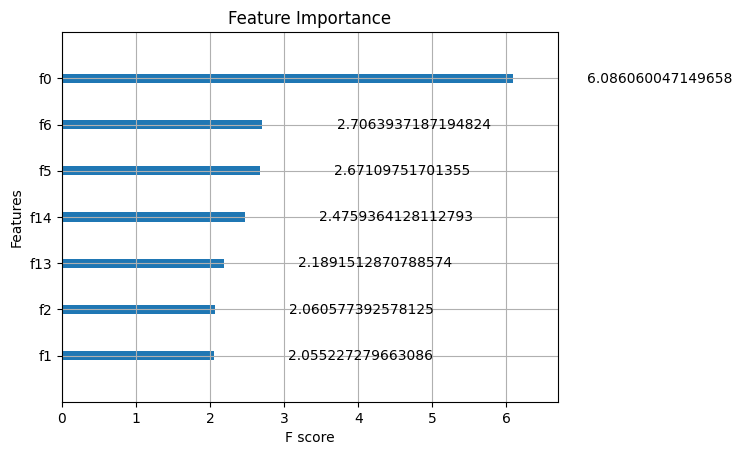

In [24]:
# ------------------------------
# 4. Evaluate the Model
# ------------------------------

# Make predictions on the test set
y_pred = model.predict(dtest)

print("Classification Report on Test Data:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Match Outcome Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Feature Importance
xgb.plot_importance(model, max_num_features=10, importance_type='gain', title="Feature Importance")
plt.show()


---

In [25]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------
# 1. Load and preprocess standings data
# ------------------------------

standings_df = pd.read_csv(Urls[1])
standings_df['Season'] = standings_df['Season'].astype(str)
unique_seasons_standings = sorted(standings_df['Season'].unique())

n_seasons_standings = len(unique_seasons_standings)
train_end = int(0.6 * n_seasons_standings)
val_end   = int(0.8 * n_seasons_standings)

train_seasons = unique_seasons_standings[:train_end]
val_seasons   = unique_seasons_standings[train_end:val_end]
test_seasons  = unique_seasons_standings[val_end:]

train_stand = standings_df[standings_df['Season'].isin(train_seasons)]
val_stand   = standings_df[standings_df['Season'].isin(val_seasons)]
test_stand  = standings_df[standings_df['Season'].isin(test_seasons)]

print(f"Standings - Train seasons: {train_seasons}")
print(f"Standings - Validation seasons: {val_seasons}")
print(f"Standings - Test seasons: {test_seasons}")


Standings - Train seasons: ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16']
Standings - Validation seasons: ['2016-17', '2017-18']
Standings - Test seasons: ['2018-19', '2019-20', '2020-21']


In [26]:
# ------------------------------
# 2. Select features and target for standings prediction
# ------------------------------

# For example, we might use columns: Pld, W, D, L, GF, GA, GD to predict Pts
standings_feature_cols = ['Pld', 'W', 'D', 'L', 'GF', 'GA', 'GD']
target_col = 'Pts'

# Verify that these columns exist in your data
missing = [col for col in standings_feature_cols if col not in standings_df.columns]
if missing:
    raise ValueError(f"Missing standings columns: {missing}")

def get_xy_stand(df, features, target):
    X = df[features].values
    y = df[target].values
    return X, y

X_train_st, y_train_st = get_xy_stand(train_stand, standings_feature_cols, target_col)
X_val_st, y_val_st     = get_xy_stand(val_stand, standings_feature_cols, target_col)
X_test_st, y_test_st   = get_xy_stand(test_stand, standings_feature_cols, target_col)

# Scaling can help with regression models
scaler_st = StandardScaler()
X_train_st = scaler_st.fit_transform(X_train_st)
X_val_st   = scaler_st.transform(X_val_st)
X_test_st  = scaler_st.transform(X_test_st)


In [27]:
# ------------------------------
# 3. Train the XGBoost Regressor
# ------------------------------

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(
    X_train_st, y_train_st,
    eval_set=[(X_train_st, y_train_st), (X_val_st, y_val_st)],
    # early_stopping_rounds=20,
    verbose=True
)


[0]	validation_0-rmse:14.80687	validation_1-rmse:17.46633
[1]	validation_0-rmse:13.49304	validation_1-rmse:16.08981
[2]	validation_0-rmse:12.31865	validation_1-rmse:14.79049
[3]	validation_0-rmse:11.24408	validation_1-rmse:13.65947
[4]	validation_0-rmse:10.27247	validation_1-rmse:12.62772
[5]	validation_0-rmse:9.37268	validation_1-rmse:11.58845
[6]	validation_0-rmse:8.60754	validation_1-rmse:10.73837
[7]	validation_0-rmse:7.92010	validation_1-rmse:9.95602
[8]	validation_0-rmse:7.25045	validation_1-rmse:9.23114
[9]	validation_0-rmse:6.67219	validation_1-rmse:8.62104
[10]	validation_0-rmse:6.14106	validation_1-rmse:8.03206
[11]	validation_0-rmse:5.62919	validation_1-rmse:7.46891
[12]	validation_0-rmse:5.18045	validation_1-rmse:7.00132
[13]	validation_0-rmse:4.75368	validation_1-rmse:6.53497
[14]	validation_0-rmse:4.36103	validation_1-rmse:6.13008
[15]	validation_0-rmse:4.01189	validation_1-rmse:5.74153
[16]	validation_0-rmse:3.73006	validation_1-rmse:5.47929
[17]	validation_0-rmse:3.4569

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

Test MSE (Standings Prediction): 6.22
Test R^2 (Standings Prediction): 0.98


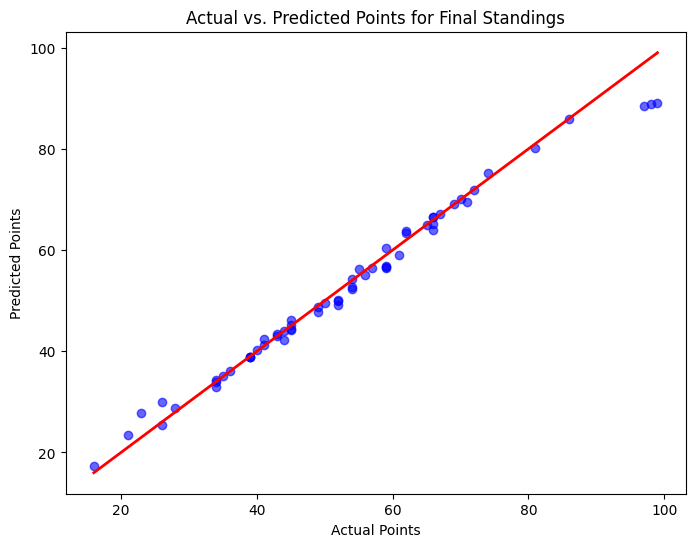

In [28]:
# ------------------------------
# 4. Evaluate the Regressor
# ------------------------------

y_pred_st = xgb_reg.predict(X_test_st)
mse = mean_squared_error(y_test_st, y_pred_st)
r2  = r2_score(y_test_st, y_pred_st)

print(f"Test MSE (Standings Prediction): {mse:.2f}")
print(f"Test R^2 (Standings Prediction): {r2:.2f}")

# Plot Actual vs. Predicted Points
plt.figure(figsize=(8,6))
plt.scatter(y_test_st, y_pred_st, color='blue', alpha=0.6)
plt.plot([min(y_test_st), max(y_test_st)], [min(y_test_st), max(y_test_st)], color='red', lw=2)
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Actual vs. Predicted Points for Final Standings")
plt.show()
